# African-domain total annual wetland CH₄ flux from JULES

Computes the **total annual wetland methane emission** over a JULES model domain from a
`fch4_wetl` output file, as a single **Tg CH₄ yr⁻¹** number.

This notebook is **standalone**: it imports no project configuration. Point `JULES_FILE`
(in the Setup cell) at your own JULES `gen_mon` NetCDF and run top to bottom.

**Requirements:** `numpy`, `xarray`, `matplotlib`, and `netCDF4` (for reading NetCDF).

**Reference result** (run `u-dc921`, tropical-Africa domain, year 1980): the flux *as stored
in the file* integrates to **~22 Tg CH₄ yr⁻¹**.

## Method (the recipe)

1. **Read** `fch4_wetl` (stored in 10⁻⁹ kg m⁻² s⁻¹, a **carbon**-mass flux) and multiply by
   `1e-9` to get physical kg C m⁻² s⁻¹.
2. **Multiply each month's flux by the number of seconds in that month, then sum the 12
   months.** `fch4_wetl` is a rate (per second), so this turns each monthly-mean rate into
   an emission [kg m⁻²] and adds them up:
   `emission = Σ_months (monthly-mean flux × seconds-in-month)`.
   (Guard: never sum the 12 bare rates and then multiply by a whole year of seconds, which
   over-counts the total by 12×.)
3. **Cell area** from the grid spacing: `area = R² · Δlat · Δlon · cos(lat)` (angles in
   radians) per land point, with `Δlat`, `Δlon` inferred from the coordinate spacing.
   `fch4_wetl` is a **gridcell-mean** flux (it already folds in wetland fraction), so
   integrate over the full cell area (do **not** multiply by wetland fraction again).
4. **Sum over space**: total = Σ_cells (per-cell annual emission × area) [kg].
5. **kg → Tg** (divide by 10⁹). This gives Tg **carbon** / yr.
6. **Carbon → methane**: × 16.043/12.011 = 1.336, giving Tg **CH₄** / yr.
7. **Optionally** apply the per-simulation calibration factor (see the last section).

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ============================ USER SETTINGS (edit) ============================
# Point this at your JULES gen_mon NetCDF (variable fch4_wetl, 1-D land grid):
JULES_FILE = ("/Users/jae35/Desktop/alice_output/GSWP3-W5E5_OBSCLIM/"
              "isimip3a_notriffid_gswp3-w5e5_obsclim_historical.gen_mon.1980.nc")

VAR          = "fch4_wetl"   # flux variable name in the file
STORE_SCALE  = 1e-9          # file units: fch4_wetl is stored in 1e-9 kg m-2 s-1 (CARBON mass)
C_TO_CH4     = 16.043/12.011 # fch4_wetl is a CARBON flux; x this (=1.336) for kg CH4
SCALE_FACTOR = 1.0           # 1.0 = flux as stored; set to a calibration factor to apply it
LAT_BAND     = None          # e.g. (-24.75, 24.75) to restrict latitude; None = whole domain
# =============================================================================

# Reference only: per-simulation global calibration factors from the data producer
# (see "The calibration factor" section at the end). Not applied unless you set SCALE_FACTOR.
METHANE_SCALING = {
    "u-dc921": 0.049023196453637716, "u-dc910": 0.04463311438319183,
    "u-de834": 0.018552474201723734, "u-de835": 0.06725514922236234,
    "u-ck917": 0.059315358460568214, "u-ck843": 0.0713952529245201,
}

plt.rcParams.update({"font.family": "sans-serif", "font.size": 10, "figure.dpi": 110})

## Load the flux and build the area weights

In [2]:
R_EARTH = 6.371e6              # m

def infer_res(coord):
    """Median grid spacing (deg) from a 1-D coordinate of repeated grid values."""
    u = np.unique(np.round(np.asarray(coord).ravel(), 6))
    d = np.diff(np.sort(u))
    return float(np.median(d[d > 1e-6]))

def load_flux(path, var=VAR, store_scale=STORE_SCALE):
    """Return lat, lon, monthly flux (time, land) [kg m-2 s-1], seconds-per-month, cell area [m2].

    Handles the JULES 1-D land layout: `var` has shape (time, y, x) with `latitude`
    and `longitude` given per land point.
    """
    ds = xr.open_dataset(path)
    lat = np.asarray(ds["latitude"].values).ravel()
    lon = np.asarray(ds["longitude"].values).ravel()
    dlat, dlon = infer_res(lat), infer_res(lon)
    area = (R_EARTH * np.deg2rad(dlat)) * (R_EARTH * np.deg2rad(dlon) * np.cos(np.deg2rad(lat)))
    flux = ds[var].values.astype("float64") * store_scale     # -> kg m-2 s-1
    flux = flux.reshape(flux.shape[0], -1)                     # (time, land)
    # seconds each monthly mean represents, from the file's own calendar
    # (handles the JULES 360-day calendar and leap years automatically)
    try:
        sec_per_month = ds["time"].dt.days_in_month.values.astype("float64") * 86400.0
    except (AttributeError, TypeError):
        sec_per_month = np.full(flux.shape[0], (365.0 / flux.shape[0]) * 86400.0)
    return lat, lon, flux, sec_per_month, area

def total_flux(flux, sec_per_month, area, lat=None, lat_band=None):
    """Domain annual total in Tg CARBON yr-1 (fch4_wetl is a carbon flux), optionally lat-masked.

    per-cell annual emission [kg C m-2] = SUM over months of (rate * seconds-in-month);
    domain total = SUM over cells of (emission * area). Multiply by 16.043/12.011 for Tg CH4.
    """
    emission = np.nansum(flux * sec_per_month[:, None], axis=0)  # kg C m-2 / yr
    keep = np.isfinite(emission)
    if lat_band is not None:
        keep &= (lat >= lat_band[0]) & (lat <= lat_band[1])
    return float(np.nansum(emission[keep] * area[keep]) / 1e9)

lat, lon, flux, sec_per_month, area = load_flux(JULES_FILE)
annual_mean = np.nanmean(flux, axis=0)   # kg m-2 s-1, for the map / diagnostics below

## Compute the total

In [3]:
tot = total_flux(flux, sec_per_month, area, lat, LAT_BAND)          # Tg CARBON / yr (as stored)

# per-second carbon-flux sum (kgC/s) over the masked domain -- this is what the bundled
# METHANE_SCALING factor multiplies (see "The calibration factor" section).
keep = np.isfinite(annual_mean)
if LAT_BAND is not None:
    keep &= (lat >= LAT_BAND[0]) & (lat <= LAT_BAND[1])
kgC_per_s = float(np.nansum(annual_mean[keep] * area[keep]))

print(f"file             : {JULES_FILE.split('/')[-1]}")
print(f"grid             : {infer_res(lat):.3g} x {infer_res(lon):.3g} deg  "
      f"| {int(keep.sum())} land cells | {area[keep].sum()/1e6:.3e} km2")
print(f"lat range        : {lat.min():+.2f} .. {lat.max():+.2f}")
print(f"year             : {flux.shape[0]} months, {sec_per_month.sum()/86400:.0f} days")
print(f"mean flux        : {np.nanmean(annual_mean):.3e} kg C m-2 s-1")
print(f"TOTAL (carbon)   : {tot:.2f} Tg C / yr")
print(f"TOTAL (methane)  : {tot*C_TO_CH4:.2f} Tg CH4 / yr   (x{C_TO_CH4:.3f} for C->CH4)")
if SCALE_FACTOR != 1.0:
    # correct application: bundled factor x the per-second kgC/s sum -> calibrated Tg CH4/yr
    print(f"TOTAL (calibrated): {kgC_per_s*SCALE_FACTOR:.2f} Tg CH4 / yr   "
          f"(METHANE_SCALING x kgC/s)")

file             : isimip3a_notriffid_gswp3-w5e5_obsclim_historical.gen_mon.1980.nc
grid             : 0.5 x 0.5 deg  | 9034 land cells | 2.698e+07 km2
lat range        : -24.75 .. +24.75
year             : 12 months, 365 days
mean flux        : 2.537e-11 kg C m-2 s-1
TOTAL (carbon)   : 22.09 Tg C / yr
TOTAL (methane)  : 29.51 Tg CH4 / yr   (x1.336 for C->CH4)


## Spatial pattern (sanity check)

The annual-mean gridcell flux in mg CH₄ m⁻² day⁻¹. Values are gridcell means (wetland
fraction already applied), so hotspots sit over the productive wetlands and most of the
domain is near zero. Uses a plain scatter of the land points, so no mapping library is
required.

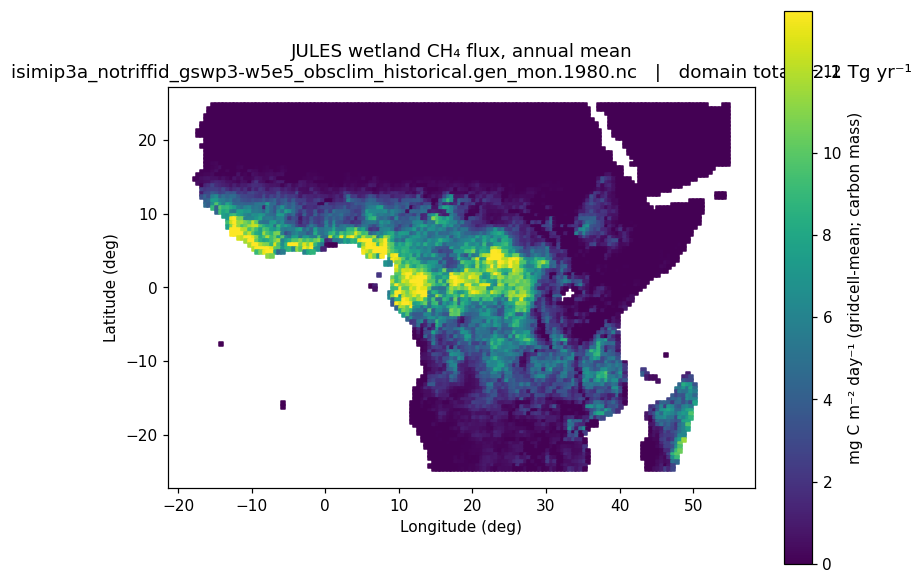

In [4]:
mgday = annual_mean * 1e6 * 86400.0     # kg m-2 s-1 -> mg m-2 day-1

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sc = ax.scatter(lon, lat, c=mgday, s=7, marker="s", cmap="viridis",
                vmin=0, vmax=np.nanpercentile(mgday, 99))
ax.set_aspect("equal")
ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Latitude (deg)")
ax.set_title(f"JULES wetland CH₄ flux, annual mean\n"
             f"{JULES_FILE.split('/')[-1]}   |   domain total {tot:.1f} Tg yr⁻¹")
cb = fig.colorbar(sc, ax=ax, shrink=0.85)
cb.set_label("mg C m⁻² day⁻¹ (gridcell-mean; carbon mass)")
plt.show()

## Caveats and refinements

- **Gridcell-mean, not per-wetland.** `fch4_wetl` is the flux the atmosphere sees per
  gridcell (wetland fraction already applied), so we integrate over the full cell area.
  Do not additionally multiply by wetland fraction.
- **Calendar / month length.** Each monthly mean is weighted by its own length via
  `time.dt.days_in_month`, so the JULES **360-day** calendar and leap years are handled
  automatically. If the time axis cannot be decoded, the code falls back to equal-length
  months summing to 365 days.
- **Area.** We compute cell area from the coordinate spacing. If your file carries an area
  variable (some products do, e.g. `cell_area` / `sf_area`), use that instead.
- **Multiple years.** Loop `load_flux` / `total_flux` over a set of yearly files and average
  the totals for a climatological figure.
- **Other grids.** For a regular 2-D grid `(time, lat, lon)`, replace the 1-D land reshape
  with a `cos(lat)` weight broadcast over longitude.

## The calibration factor (important)

The data producer's per-run factor (the `METHANE_SCALING` dict above; u-dc921 = 0.049) is **not**
a pure calibration multiplier. It **bundles a unit conversion with a mild calibration**:

`0.049 = 0.0420768 × 1.165`, where `0.0420768 = (16/12) × (365.25-day year × 86400) × 1e-9` is
the `kgC/s → TgCH₄/yr` unit conversion (carbon→methane, per-second→per-year, kg→Tg), and `1.165`
is the calibration bringing the run's **global** total to 180 Tg CH₄ yr⁻¹ (JULES global
uncalibrated ≈ 154).

**Apply it to the per-second carbon-flux SUM (kgC/s), not to a number already in Tg/yr.** If you
multiply an already-converted Tg/yr total by 0.049 you re-do the unit conversion and collapse the
answer ~20× (a spurious ~1 Tg/yr). Correct form (as in the compute cell):

```python
kgC_per_s = np.nansum((annual_mean * area)[np.isfinite(annual_mean)])   # domain mean-rate sum
calibrated_TgCH4_yr = kgC_per_s * METHANE_SCALING['u-dc921']
```

This gives tropical Africa ≈ **34 Tg CH₄ yr⁻¹** (28–35 across all six runs), consistent with the
independent GEOS-Chem/GOSAT wetland inversion (~31 bottom-up prior, ~47 posterior). The
uncalibrated methane total (carbon × 1.336) is ≈ 29 Tg CH₄ yr⁻¹, already ≈ the GOSAT prior.

**Open with the data producer:** whether the 180 Tg target / the internal `const_ch4` was set in
CH₄ mass or carbon mass (decides whether the ×16/12 is applied fresh or already absorbed in the
constant), and proper month-weighting. Confirm before treating the exact calibrated number as final.